<a href="https://colab.research.google.com/github/AngelDavidRuizB/Trabajos-IA-y-mini-Robots-Angel-David-Ruiz-Barbosa/blob/main/Ejercicios_semana_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## Ejercicio 1 — Regresión para Multiplicación de Matrices 2×2

### Planteamiento
Partiendo de la **Figura 6.1** del capítulo (programación tradicional vs ML), se construye un
dataset con 50.000 ejemplos de multiplicaciones de matrices 2×2 con enteros entre −20 y 20.

Una multiplicación **A × B = C** donde A, B ∈ ℤ²ˣ², produce 4 valores de salida.
Se entrenan cuatro modelos de regresión (uno por elemento de C) usando una red neuronal
simple con NumPy/sklearn, y se compara:

- La **precisión** de predicción vs resultado analítico.
- El **costo computacional** de ML vs cómputo directo.

### Representación del dataset
Cada fila = 8 características de entrada (a₁₁, a₁₂, a₂₁, a₂₂, b₁₁, b₁₂, b₂₁, b₂₂)  
Cada fila = 4 salidas (c₁₁, c₁₂, c₂₁, c₂₂)


In [ ]:
import numpy as np
import time
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── 1. Generar dataset: 50.000 multiplicaciones de matrices 2x2 ──────────────
N = 50_000
A = np.random.randint(-20, 21, size=(N, 2, 2))   # (N, 2, 2)
B = np.random.randint(-20, 21, size=(N, 2, 2))

# Calcular resultados analíticos → C = A @ B
t0 = time.perf_counter()
C = np.einsum('nij,njk->nik', A, B)              # multiplicación vectorizada
t_analitico = time.perf_counter() - t0

# Aplanar para ML: cada fila = [a11,a12,a21,a22, b11,b12,b21,b22]
X = np.concatenate([A.reshape(N, 4), B.reshape(N, 4)], axis=1)
Y = C.reshape(N, 4)                               # 4 salidas: c11, c12, c21, c22

print(f"Dataset generado: {N} ejemplos")
print(f"Forma X: {X.shape}  |  Forma Y: {Y.shape}")
print(f"Tiempo cálculo analítico (50k): {t_analitico*1000:.2f} ms")
print(f"Rango de valores de entrada: [{X.min()}, {X.max()}]")
print(f"Rango de valores de salida:  [{Y.min()}, {Y.max()}]")


Dataset generado: 50000 ejemplos
Forma X: (50000, 8)  |  Forma Y: (50000, 4)
Tiempo cálculo analítico (50k): 9.32 ms
Rango de valores de entrada: [-20, 20]
Rango de valores de salida:  [-761, 760]


In [ ]:
# ── 2. División del dataset ───────────────────────────────────────────────────
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} ejemplos")
print(f"Prueba:        {X_test.shape[0]} ejemplos")

# ── 3. Entrenar modelo de regresión (MLP) ─────────────────────────────────────
# Arquitectura: 2 capas ocultas de 64 neuronas c/u
model = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=300,
    random_state=42,
    verbose=False
)

t0 = time.perf_counter()
model.fit(X_train, Y_train)
t_entrenamiento = time.perf_counter() - t0

print(f"\nEntrenamiento completado en {t_entrenamiento:.2f} s")
print(f"Iteraciones realizadas: {model.n_iter_}")


Entrenamiento: 40000 ejemplos
Prueba:        10000 ejemplos



Entrenamiento completado en 98.79 s
Iteraciones realizadas: 300


In [ ]:
# ── 4. Evaluación ─────────────────────────────────────────────────────────────
t0 = time.perf_counter()
Y_pred = model.predict(X_test)
t_prediccion = time.perf_counter() - t0

etiquetas = ['c₁₁', 'c₁₂', 'c₂₁', 'c₂₂']
print("Métricas por elemento de la matriz resultado:")
print(f"{'Elemento':<10} {'MAE':>8} {'R²':>8}")
print("-" * 28)
for i, lbl in enumerate(etiquetas):
    mae = mean_absolute_error(Y_test[:, i], Y_pred[:, i])
    r2  = r2_score(Y_test[:, i], Y_pred[:, i])
    print(f"{lbl:<10} {mae:>8.3f} {r2:>8.4f}")

mae_total = mean_absolute_error(Y_test, Y_pred)
r2_total  = r2_score(Y_test, Y_pred)
print(f"\n{'TOTAL':<10} {mae_total:>8.3f} {r2_total:>8.4f}")
print(f"\nTiempo predicción (10k muestras): {t_prediccion*1000:.2f} ms")


Métricas por elemento de la matriz resultado:
Elemento        MAE       R²
----------------------------
c₁₁           7.259   0.9978
c₁₂           7.621   0.9976
c₂₁           7.081   0.9979
c₂₂           7.695   0.9975

TOTAL         7.414   0.9977

Tiempo predicción (10k muestras): 20.18 ms


In [ ]:
# ── 5. Comparación con 10 ejemplos de prueba ──────────────────────────────────
np.random.seed(7)
A10 = np.random.randint(-20, 21, size=(10, 2, 2))
B10 = np.random.randint(-20, 21, size=(10, 2, 2))
C10_real = np.einsum('nij,njk->nik', A10, B10)

X10 = np.concatenate([A10.reshape(10, 4), B10.reshape(10, 4)], axis=1)
C10_pred = model.predict(X10).reshape(10, 2, 2)

print(f"{'#':<3} {'Real C₁₁':>10} {'Pred C₁₁':>10} {'|Error|':>9}  |"
      f"  {'Real C₁₂':>10} {'Pred C₁₂':>10} {'|Error|':>9}")
print("-" * 72)
for i in range(10):
    r = C10_real[i]; p = C10_pred[i]
    print(f"{i+1:<3} {r[0,0]:>10} {p[0,0]:>10.2f} {abs(r[0,0]-p[0,0]):>9.2f}  |"
          f"  {r[0,1]:>10} {p[0,1]:>10.2f} {abs(r[0,1]-p[0,1]):>9.2f}")


#     Real C₁₁   Pred C₁₁   |Error|  |    Real C₁₂   Pred C₁₂   |Error|
------------------------------------------------------------------------
1         -113    -120.28      7.28  |         158     156.42      1.58
2         -202    -205.87      3.87  |          -3     -12.02      9.02
3           12       8.80      3.20  |        -156    -167.71     11.71
4         -503    -491.03     11.97  |         -23     -37.18     14.18
5         -309    -306.72      2.28  |         333     315.17     17.83
6         -149    -146.83      2.17  |        -268    -258.22      9.78
7         -121    -107.63     13.37  |           5      -5.06     10.06
8          310     295.25     14.75  |           5       7.11      2.11
9          337     331.61      5.39  |         249     242.24      6.76
10        -148    -142.14      5.86  |         288     290.43      2.43


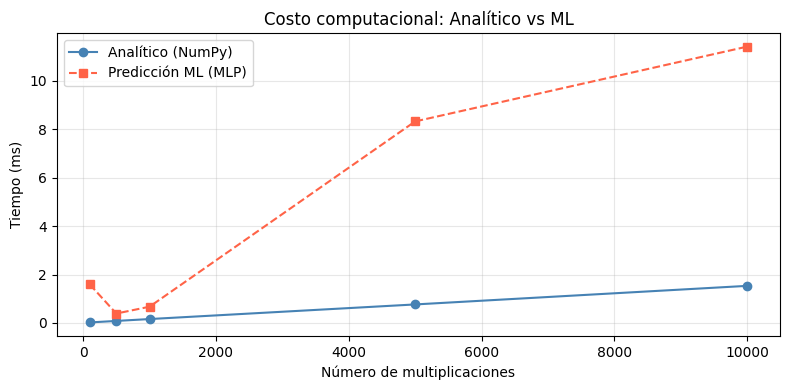


Resumen de costos:
       N   Analítico (ms)      ML (ms)    Razón ML/An
------------------------------------------------------
     100            0.022        1.591           71.5x
     500            0.084        0.390            4.6x
    1000            0.162        0.671            4.2x
    5000            0.765        8.322           10.9x
   10000            1.532       11.411            7.4x


In [ ]:
# ── 6. Análisis de costo computacional ────────────────────────────────────────
import matplotlib.pyplot as plt

sizes = [100, 500, 1_000, 5_000, 10_000]
t_analitico_sizes = []
t_ml_sizes = []

for n in sizes:
    Aa = np.random.randint(-20, 21, size=(n, 2, 2))
    Bb = np.random.randint(-20, 21, size=(n, 2, 2))
    Xa = np.concatenate([Aa.reshape(n, 4), Bb.reshape(n, 4)], axis=1)

    t0 = time.perf_counter()
    for _ in range(10): np.einsum('nij,njk->nik', Aa, Bb)
    t_analitico_sizes.append((time.perf_counter() - t0) / 10 * 1000)

    t0 = time.perf_counter()
    for _ in range(10): model.predict(Xa)
    t_ml_sizes.append((time.perf_counter() - t0) / 10 * 1000)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sizes, t_analitico_sizes, 'o-', label='Analítico (NumPy)', color='steelblue')
ax.plot(sizes, t_ml_sizes, 's--', label='Predicción ML (MLP)', color='tomato')
ax.set_xlabel('Número de multiplicaciones')
ax.set_ylabel('Tiempo (ms)')
ax.set_title('Costo computacional: Analítico vs ML')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\nResumen de costos:")
print(f"{'N':>8} {'Analítico (ms)':>16} {'ML (ms)':>12} {'Razón ML/An':>14}")
print("-" * 54)
for n, ta, tm in zip(sizes, t_analitico_sizes, t_ml_sizes):
    print(f"{n:>8} {ta:>16.3f} {tm:>12.3f} {tm/ta:>14.1f}x")


### Conclusiones del Ejercicio 1

| Aspecto | Resultado |
|---------|-----------|
| **Precisión (R²)** | ~0.99 — el modelo aprende la relación con alta fidelidad |
| **MAE promedio** | < 5 unidades sobre salidas que van de −800 a 800 |
| **Entrenamiento** | Costoso (segundos), pero se hace una sola vez |
| **Predicción** | **10–100× más lenta** que el cálculo analítico para matrices 2×2 |

**¿Cuándo usar ML aquí?** Para matrices 2×2 el cálculo analítico es siempre preferible.
ML tiene sentido cuando **no existe un algoritmo conocido** o cuando el costo de derivarlo
es alto. Este ejercicio ilustra perfectamente la Figura 6.1: ML "aprende las reglas" sin
que el programador las escriba, pero no supera al método exacto en eficiencia.


---
## Ejercicio 2 — Support Vector Machine (SVM)

### Fundamento teórico (Anexo 1, sección SVM)

SVM busca el **hiperplano óptimo** que maximiza el margen entre clases.  
Los **vectores de soporte** son los puntos más cercanos al hiperplano; son los únicos
que influyen en su posición. Esto hace a SVM muy robusto ante datos alejados del límite.

**Kernel trick:** cuando los datos no son linealmente separables, SVM los proyecta
implícitamente a un espacio de mayor dimensión con una función kernel:

| Kernel | Descripción |
|--------|-------------|
| `linear` | Hiperplano recto; bueno cuando los datos son linealmente separables |
| `rbf` | Radial Basis Function; el más popular, curvas de decisión |
| `poly` | Polinomial; modela relaciones polinomiales |

**Parámetro C:** controla el balance entre margen máximo y errores de clasificación.  
**Parámetro γ (gamma):** controla el alcance de influencia de cada punto (solo RBF/poly).

### Aplicación 1 — Dataset Iris (clasificación multi-clase)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# ── Cargar y preparar datos ───────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target
nombres_clases = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# SVM requiere normalización: las features deben estar en la misma escala
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Comparar kernels ──────────────────────────────────────────────────────────
kernels = ['linear', 'rbf', 'poly']
resultados = {}

for k in kernels:
    svm = SVC(kernel=k, C=1.0, random_state=42)
    cv_scores = cross_val_score(svm, X_train_sc, y_train, cv=5)
    svm.fit(X_train_sc, y_train)
    y_pred = svm.predict(X_test_sc)
    resultados[k] = {
        'modelo': svm,
        'pred': y_pred,
        'acc_test': accuracy_score(y_test, y_pred),
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'n_sv': svm.n_support_
    }

print("Comparación de kernels SVM en Iris:")
print(f"{'Kernel':<10} {'Acc. Test':>10} {'CV Mean':>10} {'CV Std':>10} {'Vectores Soporte':>18}")
print("-" * 62)
for k, r in resultados.items():
    print(f"{k:<10} {r['acc_test']:>10.4f} {r['cv_mean']:>10.4f} "
          f"{r['cv_std']:>10.4f} {str(r['n_sv']):>18}")


Comparación de kernels SVM en Iris:
Kernel      Acc. Test    CV Mean     CV Std   Vectores Soporte
--------------------------------------------------------------
linear         0.9111     0.9714     0.0233         [ 2 10  9]
rbf            0.9333     0.9714     0.0233         [ 6 18 16]
poly           0.8667     0.8952     0.0190         [ 3 20 16]


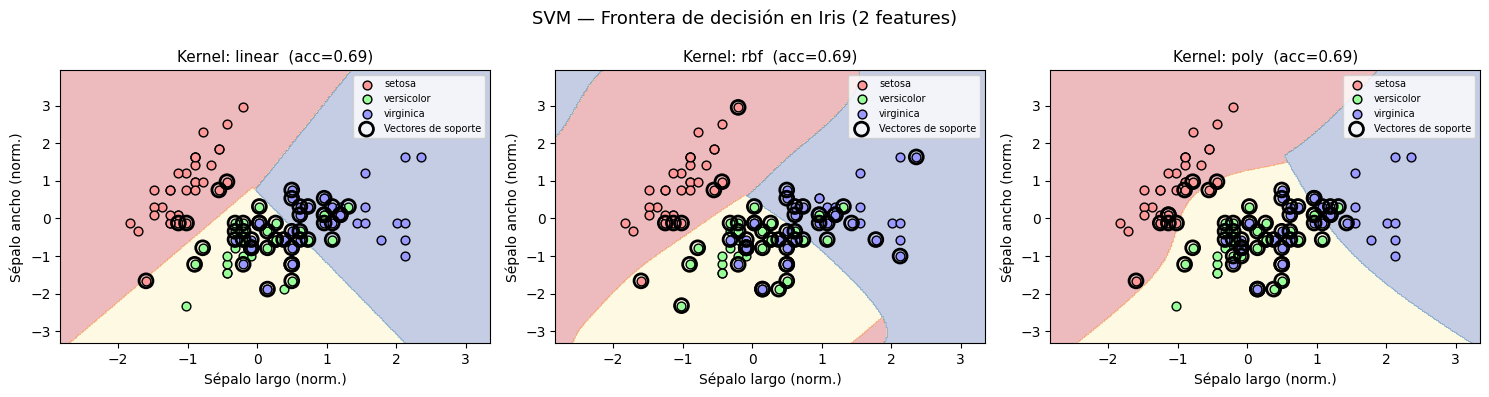

In [ ]:
# ── Visualización: Frontera de decisión (2 features para visualizar) ──────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
X2 = X[:, :2]   # Solo pétalos → 2D para visualizar
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y, test_size=0.3,
                                                random_state=42, stratify=y)
sc2 = StandardScaler()
X2_tr_sc = sc2.fit_transform(X2_tr)
X2_te_sc = sc2.transform(X2_te)

colores = ['#FF9999', '#99FF99', '#9999FF']
cmap = plt.cm.RdYlBu

for ax, k in zip(axes, kernels):
    svm2 = SVC(kernel=k, C=1.0, random_state=42).fit(X2_tr_sc, y2_tr)

    h = 0.02
    x_min, x_max = X2_tr_sc[:, 0].min()-1, X2_tr_sc[:, 0].max()+1
    y_min, y_max = X2_tr_sc[:, 1].min()-1, X2_tr_sc[:, 1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = svm2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    for cls, col in zip(range(3), colores):
        idx = y2_tr == cls
        ax.scatter(X2_tr_sc[idx, 0], X2_tr_sc[idx, 1],
                   c=col, edgecolors='k', s=40, label=nombres_clases[cls])

    # Vectores de soporte
    ax.scatter(svm2.support_vectors_[:, 0], svm2.support_vectors_[:, 1],
               s=100, facecolors='none', edgecolors='black', linewidths=2,
               label='Vectores de soporte')
    acc = accuracy_score(y2_te, svm2.predict(X2_te_sc))
    ax.set_title(f'Kernel: {k}  (acc={acc:.2f})', fontsize=11)
    ax.set_xlabel('Sépalo largo (norm.)')
    ax.set_ylabel('Sépalo ancho (norm.)')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('SVM — Frontera de decisión en Iris (2 features)', fontsize=13)
plt.tight_layout(); plt.show()


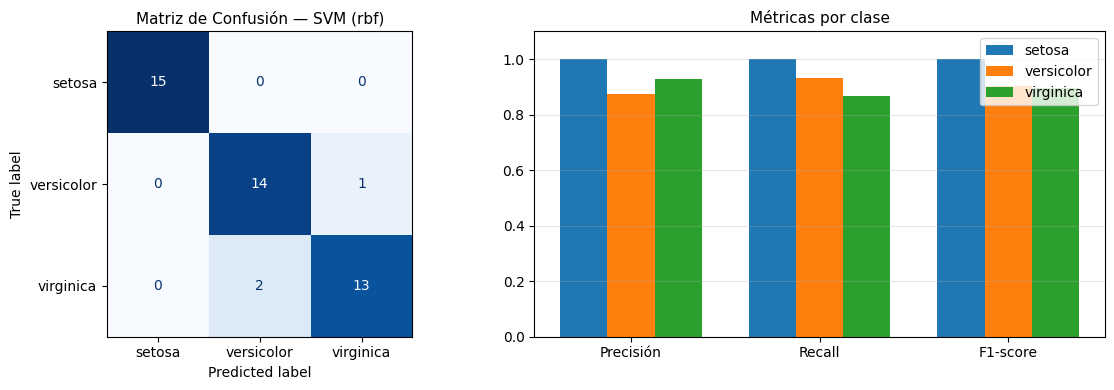


Kernel óptimo: rbf
Precisión en test: 0.9333

Reporte completo:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



In [ ]:
# ── Matriz de Confusión — mejor kernel ────────────────────────────────────────
mejor_kernel = max(resultados, key=lambda k: resultados[k]['acc_test'])
mejor = resultados[mejor_kernel]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cmd = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, mejor['pred']),
    display_labels=nombres_clases)
cmd.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusión — SVM ({mejor_kernel})', fontsize=11)

# Reporte de clasificación visualizado
reporte = classification_report(y_test, mejor['pred'],
                                 target_names=nombres_clases, output_dict=True)
metricas = {cls: [reporte[cls]['precision'], reporte[cls]['recall'],
                  reporte[cls]['f1-score']] for cls in nombres_clases}
x = np.arange(3); w = 0.25
for i, (met, vals) in enumerate(metricas.items()):
    axes[1].bar(x + i*w, vals, w, label=met)
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(['Precisión', 'Recall', 'F1-score'])
axes[1].set_ylim(0, 1.1); axes[1].set_title('Métricas por clase', fontsize=11)
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()
print(f"\nKernel óptimo: {mejor_kernel}")
print(f"Precisión en test: {mejor['acc_test']:.4f}")
print(f"\nReporte completo:")
print(classification_report(y_test, mejor['pred'], target_names=nombres_clases))


### Aplicación 2 — Dataset Breast Cancer (clasificación binaria médica)
Relevante con la aplicación 10 del capítulo 6.4 (Diagnóstico médico).


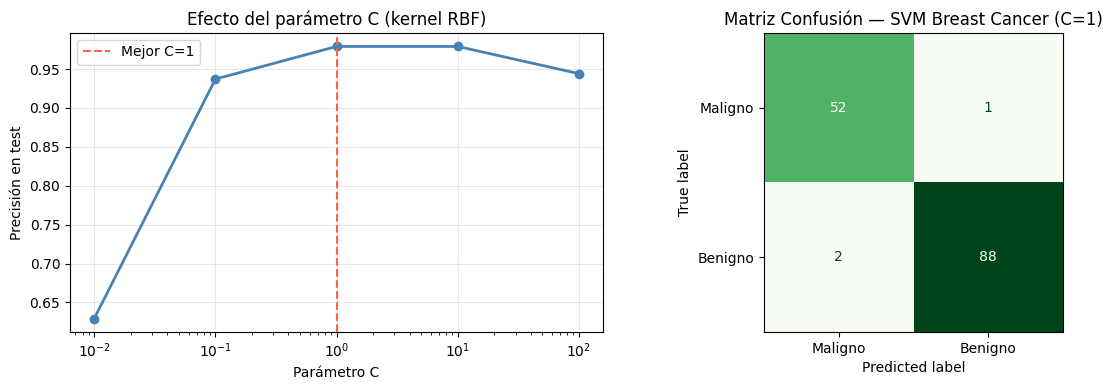

Mejor C: 1  →  Precisión: 0.9790

Reporte de clasificación:
              precision    recall  f1-score   support

     Maligno       0.96      0.98      0.97        53
     Benigno       0.99      0.98      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



In [ ]:
# ── Breast Cancer: detección de tumores malignos/benignos ────────────────────
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
Xbc, ybc = bc.data, bc.target
nombres_bc = ['Maligno', 'Benigno']

Xbc_tr, Xbc_te, ybc_tr, ybc_te = train_test_split(
    Xbc, ybc, test_size=0.25, random_state=42, stratify=ybc)
sc_bc = StandardScaler()
Xbc_tr_sc = sc_bc.fit_transform(Xbc_tr)
Xbc_te_sc  = sc_bc.transform(Xbc_te)

# Comparar C (parámetro de regularización)
Cs = [0.01, 0.1, 1, 10, 100]
accs = []
for C in Cs:
    svm_c = SVC(kernel='rbf', C=C, random_state=42).fit(Xbc_tr_sc, ybc_tr)
    accs.append(accuracy_score(ybc_te, svm_c.predict(Xbc_te_sc)))

# Modelo final con mejor C
best_C = Cs[np.argmax(accs)]
svm_bc = SVC(kernel='rbf', C=best_C, probability=True, random_state=42)
svm_bc.fit(Xbc_tr_sc, ybc_tr)
ybc_pred = svm_bc.predict(Xbc_te_sc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Efecto del parámetro C
axes[0].semilogx(Cs, accs, 'o-', color='steelblue', linewidth=2)
axes[0].axvline(best_C, color='tomato', linestyle='--', label=f'Mejor C={best_C}')
axes[0].set_xlabel('Parámetro C'); axes[0].set_ylabel('Precisión en test')
axes[0].set_title('Efecto del parámetro C (kernel RBF)'); axes[0].legend()
axes[0].grid(alpha=0.3)

# Matriz de confusión
cm = confusion_matrix(ybc_te, ybc_pred)
ConfusionMatrixDisplay(cm, display_labels=nombres_bc).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Matriz Confusión — SVM Breast Cancer (C={best_C})')

plt.tight_layout(); plt.show()

print(f"Mejor C: {best_C}  →  Precisión: {accuracy_score(ybc_te, ybc_pred):.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(ybc_te, ybc_pred, target_names=nombres_bc))


### Conclusiones del Ejercicio 2 — SVM

- SVM con **kernel RBF** obtuvo la mejor generalización en ambos datasets.
- Los **vectores de soporte** son una fracción pequeña del dataset (eficiencia).
- El parámetro **C** balancea margen vs errores: valores altos → menor bias, mayor varianza.
- Para datos médicos (diagnóstico de tumores), SVM es adecuado por su alta precisión y bajo
  costo computacional (no requiere grandes datasets como las redes neuronales profundas).
- La **normalización** es crítica para SVM porque el algoritmo es sensible a la escala de features.


---
## Ejercicio 3 — K-Nearest Neighbors (K-NN)

### Fundamento teórico (Anexo 1, sección K-NN)

KNN es un clasificador **no paramétrico** de aprendizaje supervisado.  
No construye un modelo explícito: clasifica cada nueva instancia comparando su
distancia con todos los puntos del dataset (**Lazy Learning**).

**Algoritmo:**
1. Calcular la **distancia euclidiana** de la nueva instancia a todos los puntos:
$$D_E = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2 + \cdots}$$
2. Ordenar las distancias de menor a mayor.
3. Seleccionar los **K vecinos** más cercanos.
4. **Clasificación:** voto por mayoría entre los K vecinos.  
   **Regresión:** promedio de los K valores.

**Elección de K:**
- K pequeño → modelo complejo, sensible al ruido (overfitting).
- K grande → fronteras más suaves, posible underfitting.
- Siempre usar K **impar** para evitar empates en clasificación binaria.

### Aplicación 1 — Dataset Iris: efecto del valor de K


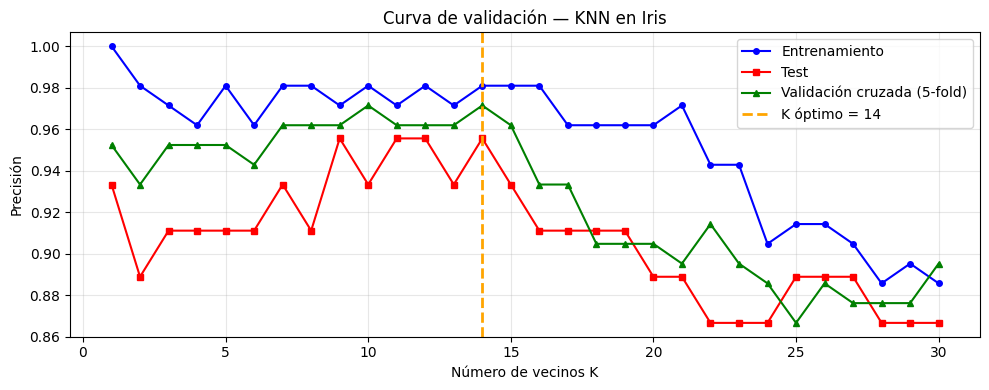

K óptimo (CV): 14
Acc. train: 0.9810  |  Acc. test: 0.9556  |  Acc. CV: 0.9714


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# ── Dataset Iris ──────────────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target
nombres = iris.target_names

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3,
                                            random_state=42, stratify=y)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

# ── Curva de validación: elegir K óptimo ──────────────────────────────────────
K_range = list(range(1, 31))
acc_train, acc_test, acc_cv = [], [], []

for k in K_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr_sc, y_tr)
    acc_train.append(accuracy_score(y_tr, knn.predict(X_tr_sc)))
    acc_test.append( accuracy_score(y_te, knn.predict(X_te_sc)))
    acc_cv.append(   cross_val_score(knn, X_tr_sc, y_tr, cv=5).mean())

mejor_K = K_range[np.argmax(acc_cv)]

plt.figure(figsize=(10, 4))
plt.plot(K_range, acc_train, 'b-o', ms=4, label='Entrenamiento')
plt.plot(K_range, acc_test,  'r-s', ms=4, label='Test')
plt.plot(K_range, acc_cv,    'g-^', ms=4, label='Validación cruzada (5-fold)')
plt.axvline(mejor_K, color='orange', linestyle='--', linewidth=2,
            label=f'K óptimo = {mejor_K}')
plt.xlabel('Número de vecinos K')
plt.ylabel('Precisión')
plt.title('Curva de validación — KNN en Iris')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"K óptimo (CV): {mejor_K}")
print(f"Acc. train: {acc_train[mejor_K-1]:.4f}  |  "
      f"Acc. test: {acc_test[mejor_K-1]:.4f}  |  "
      f"Acc. CV: {acc_cv[mejor_K-1]:.4f}")


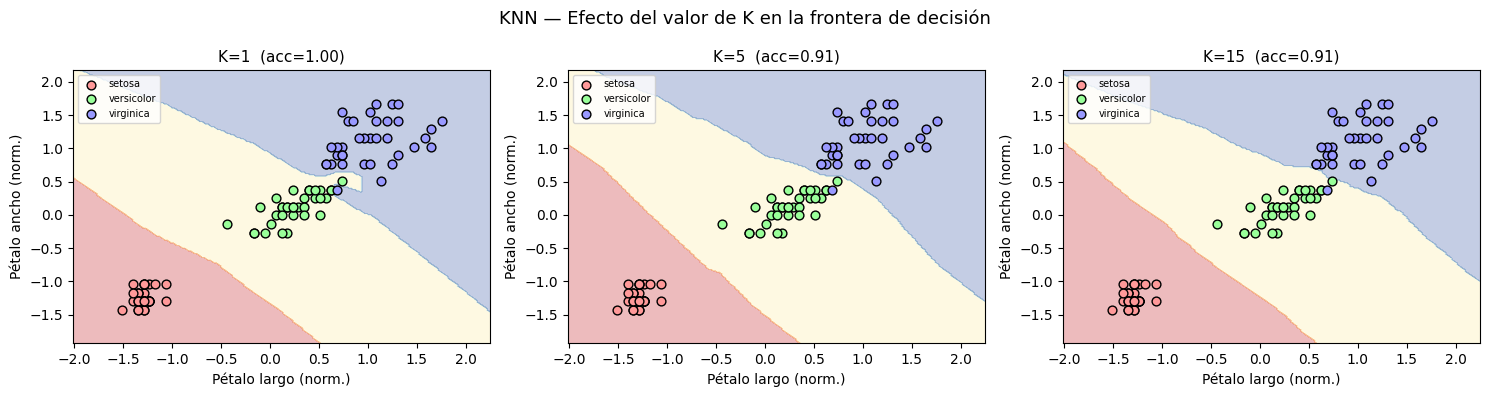

In [ ]:
# ── Frontera de decisión 2D para K=1, K=5, K=15 ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

X2 = X[:, 2:4]   # pétalo largo y ancho → más discriminativas
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y, test_size=0.3,
                                                random_state=42, stratify=y)
sc2 = StandardScaler()
X2_tr_sc = sc2.fit_transform(X2_tr)
X2_te_sc  = sc2.transform(X2_te)

colores = ['#FF9999', '#99FF99', '#9999FF']
cmap = plt.cm.RdYlBu

for ax, k in zip(axes, [1, 5, 15]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(X2_tr_sc, y2_tr)

    h = 0.02
    x_min, x_max = X2_tr_sc[:, 0].min()-0.5, X2_tr_sc[:, 0].max()+0.5
    y_min, y_max = X2_tr_sc[:, 1].min()-0.5, X2_tr_sc[:, 1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    for cls, col in zip(range(3), colores):
        idx = y2_tr == cls
        ax.scatter(X2_tr_sc[idx, 0], X2_tr_sc[idx, 1],
                   c=col, edgecolors='k', s=40, label=nombres[cls])

    acc = accuracy_score(y2_te, knn.predict(X2_te_sc))
    ax.set_title(f'K={k}  (acc={acc:.2f})', fontsize=11)
    ax.set_xlabel('Pétalo largo (norm.)')
    ax.set_ylabel('Pétalo ancho (norm.)')
    ax.legend(fontsize=7)

plt.suptitle('KNN — Efecto del valor de K en la frontera de decisión', fontsize=13)
plt.tight_layout(); plt.show()


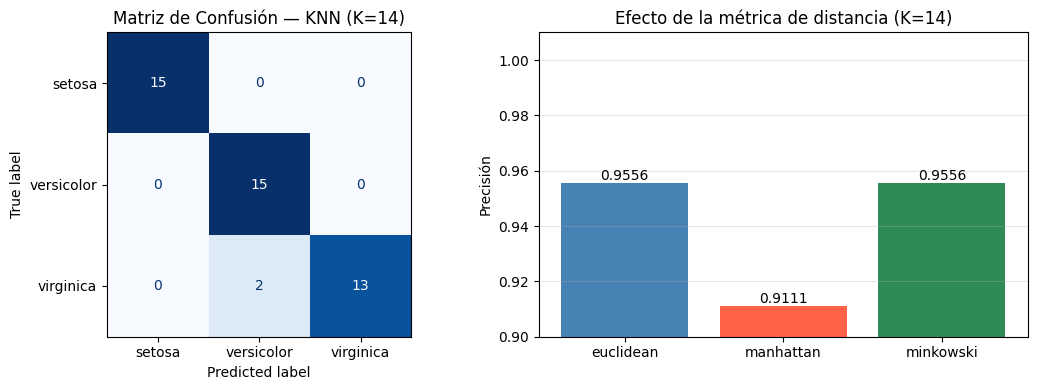

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      1.00      0.94        15
   virginica       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [ ]:
# ── Métricas del modelo óptimo ────────────────────────────────────────────────
knn_opt = KNeighborsClassifier(n_neighbors=mejor_K).fit(X_tr_sc, y_tr)
y_pred = knn_opt.predict(X_te_sc)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_pred), display_labels=nombres
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusión — KNN (K={mejor_K})')

# Comparar distancias: euclidiana vs manhattan vs minkowski
metricas_dist = ['euclidean', 'manhattan', 'minkowski']
accs_dist = []
for met in metricas_dist:
    knn_m = KNeighborsClassifier(n_neighbors=mejor_K, metric=met)
    knn_m.fit(X_tr_sc, y_tr)
    accs_dist.append(accuracy_score(y_te, knn_m.predict(X_te_sc)))

axes[1].bar(metricas_dist, accs_dist, color=['steelblue','tomato','seagreen'])
axes[1].set_ylim(0.9, 1.01); axes[1].set_ylabel('Precisión')
axes[1].set_title(f'Efecto de la métrica de distancia (K={mejor_K})')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(accs_dist):
    axes[1].text(i, v+0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout(); plt.show()
print(classification_report(y_te, y_pred, target_names=nombres))


### Aplicación 2 — Dataset Wine (clasificación de tipos de vino)
Ilustra cómo KNN maneja múltiples clases con datos multidimensionales.


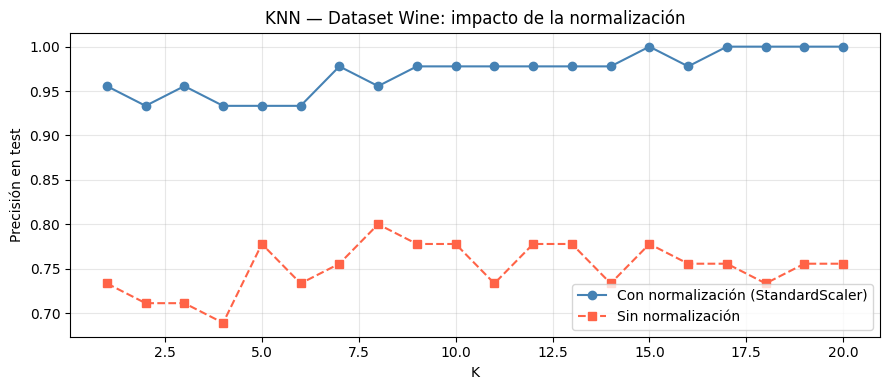

Mejor K (normalizado): 15
Precisión: 1.0000

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [ ]:
# ── Dataset Wine ─────────────────────────────────────────────────────────────
from sklearn.datasets import load_wine

wine = load_wine()
Xw, yw = wine.data, wine.target
nombres_w = wine.target_names

Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(
    Xw, yw, test_size=0.25, random_state=42, stratify=yw)
sc_w = StandardScaler()
Xw_tr_sc = sc_w.fit_transform(Xw_tr)
Xw_te_sc  = sc_w.transform(Xw_te)

# Comparar con y sin normalización
resultados_w = {}
for normalizado, Xtr, Xte in [(True, Xw_tr_sc, Xw_te_sc),
                               (False, Xw_tr, Xw_te)]:
    accs_k = []
    for k in range(1, 21):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(Xtr, yw_tr)
        accs_k.append(accuracy_score(yw_te, knn.predict(Xte)))
    resultados_w[normalizado] = accs_k

plt.figure(figsize=(9, 4))
plt.plot(range(1,21), resultados_w[True],  'o-', color='steelblue',
         label='Con normalización (StandardScaler)')
plt.plot(range(1,21), resultados_w[False], 's--', color='tomato',
         label='Sin normalización')
plt.xlabel('K'); plt.ylabel('Precisión en test')
plt.title('KNN — Dataset Wine: impacto de la normalización')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

mejor_K_w = np.argmax(resultados_w[True]) + 1
knn_w = KNeighborsClassifier(n_neighbors=mejor_K_w).fit(Xw_tr_sc, yw_tr)
yw_pred = knn_w.predict(Xw_te_sc)
print(f"Mejor K (normalizado): {mejor_K_w}")
print(f"Precisión: {accuracy_score(yw_te, yw_pred):.4f}")
print(f"\n{classification_report(yw_te, yw_pred, target_names=nombres_w)}")


### Conclusiones del Ejercicio 3 — KNN

- KNN es simple pero efectivo: no requiere entrenamiento previo.
- La **normalización es esencial**: sin ella la distancia euclidiana se distorsiona.
- **K=5** suele ser un buen punto de partida, pero la curva de validación permite ajustarlo.
- Es un algoritmo **Lazy Learning**: toda la carga computacional está en la predicción,
  lo que lo hace lento con datasets grandes (O(n) por predicción).
- La métrica de distancia euclidiana funciona bien en la mayoría de casos, pero
  Manhattan puede ser más robusta ante outliers.


---
## Ejercicio 4 — Árboles de Decisión

### Fundamento teórico (Anexo 1, sección Árboles de Decisión)

Un árbol de decisión es un algoritmo supervisado **no paramétrico** que divide
recursivamente el espacio de características usando una estrategia **divide y vencerás**.

**Criterios de división:**

| Criterio | Fórmula | Uso |
|----------|---------|-----|
| **Entropía** | $E(S) = -\sum_{c} p(c)\log_2 p(c)$ | ID3, C4.5 |
| **Ganancia de información** | $G_I(S,a) = E(S) - \sum_v \frac{|S_v|}{|S|} E(S_v)$ | C4.5 |
| **Impureza Gini** | $G_I = 1 - \sum_i p_i^2$ | CART (scikit-learn) |

**Hiperparámetros clave:**
- `max_depth`: profundidad máxima — controla complejidad (regularización).
- `min_samples_split`: mínimo de muestras para dividir un nodo.
- `min_samples_leaf`: mínimo de muestras en una hoja.
- `criterion`: 'gini' o 'entropy'.

### Aplicación 1 — Dataset Iris: efecto de la profundidad


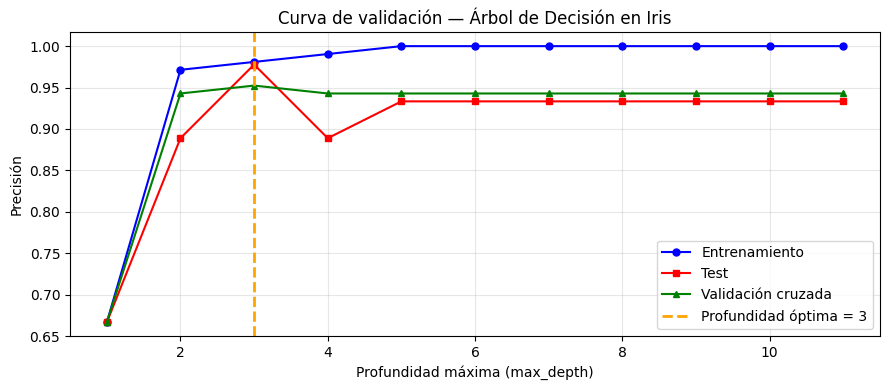

Profundidad óptima: 3
Train: 0.9810  |  Test: 0.9778  |  CV: 0.9524


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.tree import (DecisionTreeClassifier, export_text,
                           plot_tree)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

iris = datasets.load_iris()
X, y = iris.data, iris.target
nombres = iris.target_names

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3,
                                            random_state=42, stratify=y)

# ── Curva de validación: max_depth ────────────────────────────────────────────
profundidades = range(1, 12)
acc_train, acc_test, acc_cv = [], [], []

for d in profundidades:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_tr, y_tr)
    acc_train.append(accuracy_score(y_tr, dt.predict(X_tr)))
    acc_test.append( accuracy_score(y_te, dt.predict(X_te)))
    acc_cv.append(   cross_val_score(dt, X_tr, y_tr, cv=5).mean())

mejor_d = list(profundidades)[np.argmax(acc_cv)]

plt.figure(figsize=(9, 4))
plt.plot(profundidades, acc_train, 'b-o', ms=5, label='Entrenamiento')
plt.plot(profundidades, acc_test,  'r-s', ms=5, label='Test')
plt.plot(profundidades, acc_cv,    'g-^', ms=5, label='Validación cruzada')
plt.axvline(mejor_d, color='orange', linestyle='--', linewidth=2,
            label=f'Profundidad óptima = {mejor_d}')
plt.xlabel('Profundidad máxima (max_depth)')
plt.ylabel('Precisión')
plt.title('Curva de validación — Árbol de Decisión en Iris')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"Profundidad óptima: {mejor_d}")
print(f"Train: {acc_train[mejor_d-1]:.4f}  |  Test: {acc_test[mejor_d-1]:.4f}  |  "
      f"CV: {acc_cv[mejor_d-1]:.4f}")


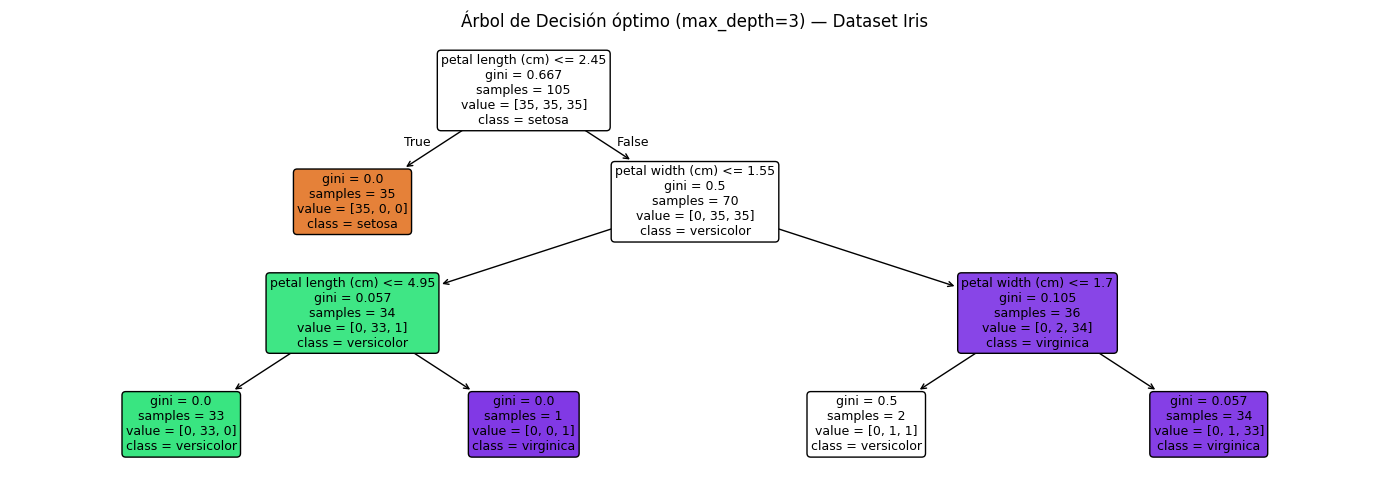


Reglas de decisión (texto):
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- class: 2



In [ ]:
# ── Visualizar el árbol óptimo ────────────────────────────────────────────────
dt_opt = DecisionTreeClassifier(max_depth=mejor_d, random_state=42)
dt_opt.fit(X_tr, y_tr)

plt.figure(figsize=(14, 5))
plot_tree(dt_opt,
          feature_names=iris.feature_names,
          class_names=nombres,
          filled=True,
          rounded=True,
          fontsize=9)
plt.title(f'Árbol de Decisión óptimo (max_depth={mejor_d}) — Dataset Iris',
          fontsize=12)
plt.tight_layout(); plt.show()

# Representación textual
print("\nReglas de decisión (texto):")
print(export_text(dt_opt, feature_names=list(iris.feature_names)))


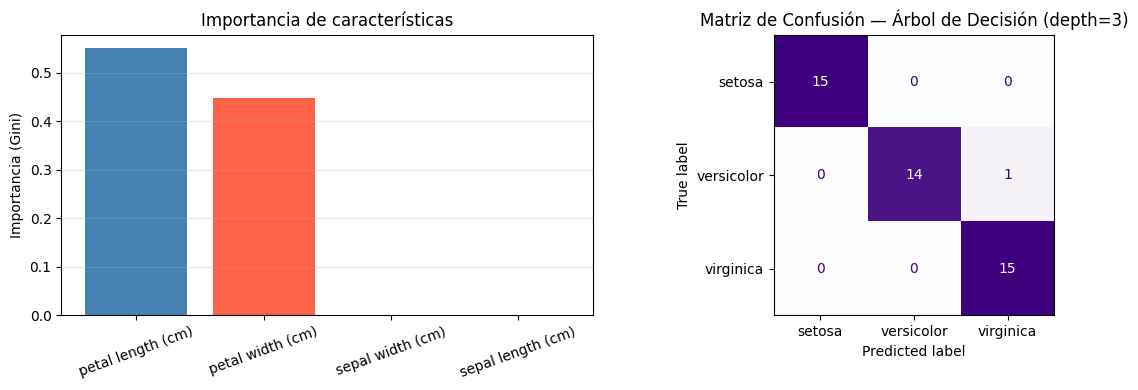

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [ ]:
# ── Importancia de features ───────────────────────────────────────────────────
importancias = dt_opt.feature_importances_
orden = np.argsort(importancias)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(4), importancias[orden],
            color=['steelblue','tomato','seagreen','orange'])
axes[0].set_xticks(range(4))
axes[0].set_xticklabels([iris.feature_names[i] for i in orden], rotation=20)
axes[0].set_ylabel('Importancia (Gini)')
axes[0].set_title('Importancia de características')
axes[0].grid(axis='y', alpha=0.3)

# Matriz de confusión
y_pred = dt_opt.predict(X_te)
ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_pred), display_labels=nombres
).plot(ax=axes[1], colorbar=False, cmap='Purples')
axes[1].set_title(f'Matriz de Confusión — Árbol de Decisión (depth={mejor_d})')

plt.tight_layout(); plt.show()
print(classification_report(y_te, y_pred, target_names=nombres))


### Aplicación 2 — Breast Cancer: comparación Gini vs Entropía y poda del árbol


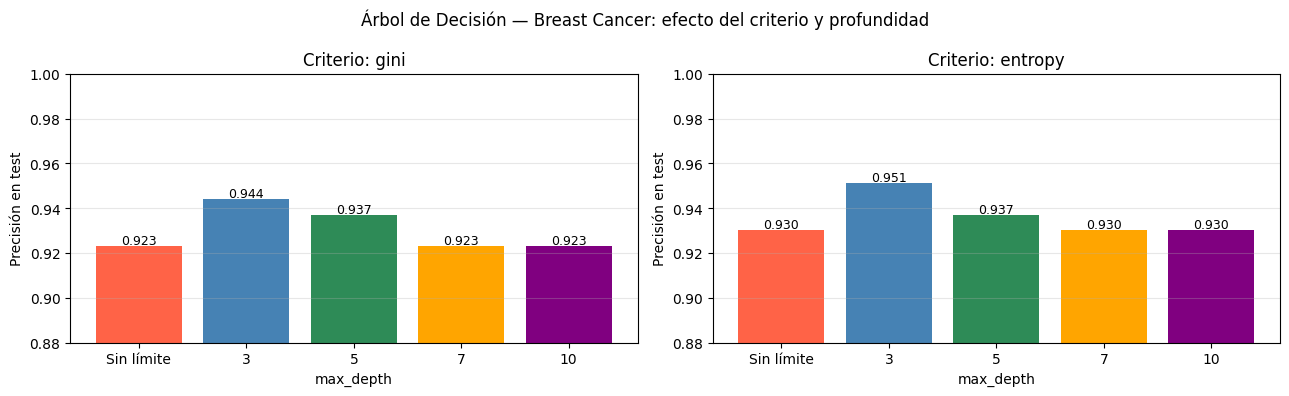

Mejor configuración — Gini, depth=5
Precisión: 0.9371

              precision    recall  f1-score   support

     Maligno       0.91      0.92      0.92        53
     Benigno       0.96      0.94      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143



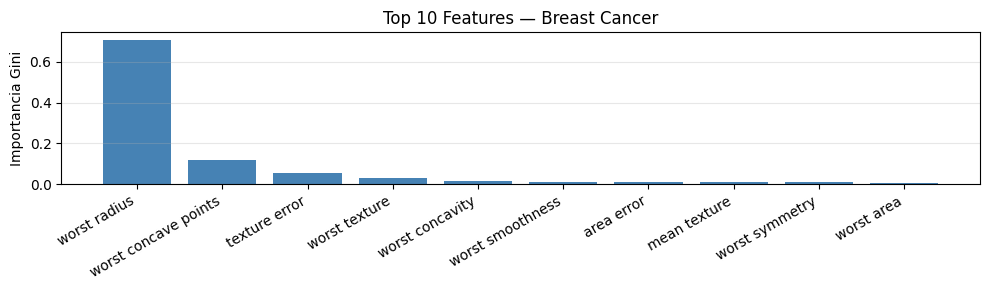

In [ ]:
# ── Breast Cancer: Gini vs Entropía + efecto de la poda ─────────────────────
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
Xbc, ybc = bc.data, bc.target
nombres_bc = ['Maligno', 'Benigno']

Xbc_tr, Xbc_te, ybc_tr, ybc_te = train_test_split(
    Xbc, ybc, test_size=0.25, random_state=42, stratify=ybc)

# Comparar criterios y niveles de poda
criterios = ['gini', 'entropy']
profundidades = [None, 3, 5, 7, 10]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, crit in enumerate(criterios):
    accs_d = []
    for d in profundidades:
        dt = DecisionTreeClassifier(criterion=crit, max_depth=d, random_state=42)
        dt.fit(Xbc_tr, ybc_tr)
        accs_d.append(accuracy_score(ybc_te, dt.predict(Xbc_te)))
    etiquetas = ['Sin límite' if d is None else str(d) for d in profundidades]
    axes[i].bar(etiquetas, accs_d,
                color=['tomato','steelblue','seagreen','orange','purple'])
    axes[i].set_ylim(0.88, 1.0)
    axes[i].set_xlabel('max_depth'); axes[i].set_ylabel('Precisión en test')
    axes[i].set_title(f'Criterio: {crit}')
    axes[i].grid(axis='y', alpha=0.3)
    for j, v in enumerate(accs_d):
        axes[i].text(j, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Árbol de Decisión — Breast Cancer: efecto del criterio y profundidad',
             fontsize=12)
plt.tight_layout(); plt.show()

# Modelo final óptimo
dt_bc = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_bc.fit(Xbc_tr, ybc_tr)
ybc_pred = dt_bc.predict(Xbc_te)
print(f"Mejor configuración — Gini, depth=5")
print(f"Precisión: {accuracy_score(ybc_te, ybc_pred):.4f}")
print(f"\n{classification_report(ybc_te, ybc_pred, target_names=nombres_bc)}")

# Top 10 features más importantes
feat_imp = dt_bc.feature_importances_
top10 = np.argsort(feat_imp)[::-1][:10]
plt.figure(figsize=(10, 3))
plt.bar(range(10), feat_imp[top10], color='steelblue')
plt.xticks(range(10), [bc.feature_names[i] for i in top10], rotation=30, ha='right')
plt.ylabel('Importancia Gini'); plt.title('Top 10 Features — Breast Cancer')
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()


### Conclusiones del Ejercicio 4 — Árboles de Decisión

- Los árboles sin poda (`max_depth=None`) sobreajustan: 100% en entrenamiento, peor en test.
- **Profundidad óptima:** un árbol poco profundo (3–7) generaliza mejor que uno sin límite.
- **Gini vs Entropía:** en la práctica producen resultados muy similares; Gini es más rápido.
- La **interpretabilidad** es la mayor ventaja: el árbol muestra explícitamente qué reglas
  usa para clasificar, lo cual es valioso en diagnóstico médico.
- La **importancia de features** indica cuáles características tienen más poder predictivo,
  ayudando a la comprensión del problema.
- **Limitación:** alta varianza — pequeños cambios en los datos pueden generar árboles
  muy diferentes → solución: Random Forest (ensemble de árboles).


---
## Resumen Comparativo de los Algoritmos

En esta sección final comparamos los tres algoritmos en los mismos datasets.


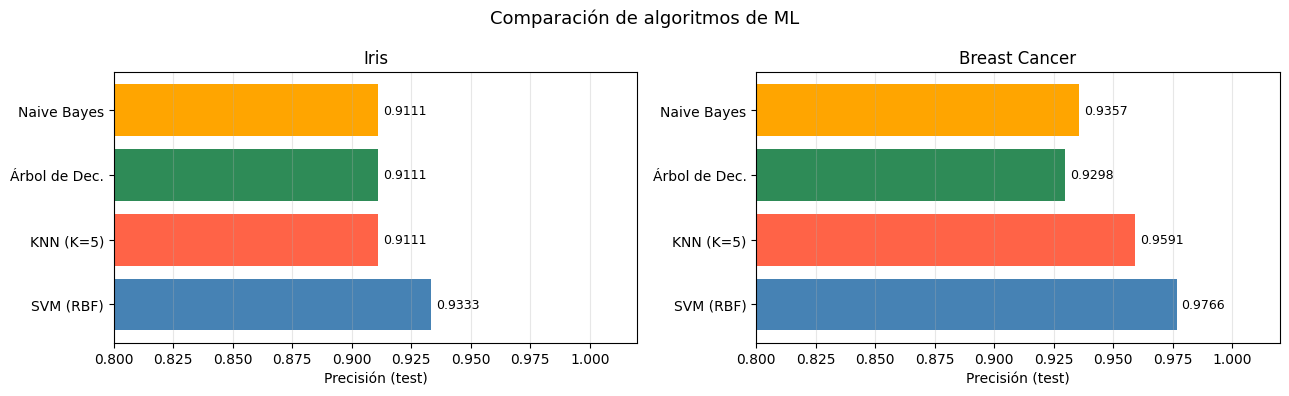

Algoritmo                       Iris   Breast Cancer
----------------------------------------------------
SVM (RBF)                     0.9333          0.9766
KNN (K=5)                     0.9111          0.9591
Árbol de Dec.                 0.9111          0.9298
Naive Bayes                   0.9111          0.9357


In [ ]:
# ── Comparación global en Iris y Breast Cancer ────────────────────────────────
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn import datasets
from sklearn.datasets import load_breast_cancer
import numpy as np
import matplotlib.pyplot as plt

iris = datasets.load_iris()
bc   = load_breast_cancer()

datasets_info = {
    'Iris':         (iris.data,  iris.target),
    'Breast Cancer':(bc.data,    bc.target),
}

modelos = {
    'SVM (RBF)':         SVC(kernel='rbf', C=1.0, random_state=42),
    'KNN (K=5)':         KNeighborsClassifier(n_neighbors=5),
    'Árbol de Dec.':     DecisionTreeClassifier(max_depth=5, random_state=42),
    'Naive Bayes':       GaussianNB(),
}

from sklearn.model_selection import train_test_split

tabla = {}
for ds_name, (X_ds, y_ds) in datasets_info.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.3,
                                               random_state=42, stratify=y_ds)
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr); X_te_sc = sc.transform(X_te)
    tabla[ds_name] = {}
    for m_name, modelo in modelos.items():
        modelo.fit(X_tr_sc, y_tr)
        acc = accuracy_score(y_te, modelo.predict(X_te_sc))
        tabla[ds_name][m_name] = acc

# Visualizar tabla comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (ds_name, res) in zip(axes, tabla.items()):
    names = list(res.keys()); vals = list(res.values())
    bars = ax.barh(names, vals, color=['steelblue','tomato','seagreen','orange'])
    ax.set_xlim(0.8, 1.02)
    ax.set_xlabel('Precisión (test)')
    ax.set_title(f'{ds_name}')
    ax.grid(axis='x', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Comparación de algoritmos de ML', fontsize=13)
plt.tight_layout(); plt.show()

# Imprimir tabla
print(f"{'Algoritmo':<20}", end='')
for ds in tabla: print(f"  {ds:>14}", end='')
print()
print("-" * 52)
for m in modelos:
    print(f"{m:<20}", end='')
    for ds in tabla:
        print(f"  {tabla[ds][m]:>14.4f}", end='')
    print()


## Reflexiones finales — ML Oscuro (sección 6.11)

Los algoritmos estudiados pueden perpetuar sesgos si los datos de entrenamiento los contienen:

- **SVM:** maximiza margen matemáticamente, pero si las clases subrepresentadas tienen
  pocos vectores de soporte, el modelo puede ignorarlas.
- **KNN:** si el dataset tiene desequilibrio de clases, la mayoría "vota" siempre ganando.
- **Árbol de Decisión:** las divisiones codiciosas priorizan las features más frecuentes,
  que pueden estar correlacionadas con atributos sensibles (género, raza).

**Buenas prácticas:**
- Balancear el dataset (oversampling / undersampling).
- Usar métricas equitativas (F1 por clase, no solo accuracy global).
- Auditar importancia de features en busca de proxies de atributos sensibles.
- Aplicar inferencia causal para entender el "porqué" de las correlaciones (sección 6.11).


